In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [4]:
start = '2012-01-01'
end = '2022-12-21'
stock ='Goog'
data = yf.download(stock,start,end)


[*********************100%***********************]  1 of 1 completed


In [5]:
data

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2012-01-03,16.438169,16.505859,16.116031,16.130114,147611217
2012-01-04,16.509071,16.557738,16.319840,16.428785,114989399
2012-01-05,16.280067,16.402599,16.211391,16.357144,131808205
2012-01-06,16.057981,16.304525,16.052298,16.283526,108119746
2012-01-09,15.377144,15.983377,15.346757,15.971023,233776981
...,...,...,...,...,...
2022-12-14,94.533882,96.428333,93.175043,94.762013,26452900
2022-12-15,90.457352,93.264309,89.693625,92.778301,28298800


In [6]:
data.reset_index(inplace= True)
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2012-01-03,16.438169,16.505859,16.116031,16.130114,147611217
1,2012-01-04,16.509071,16.557738,16.319840,16.428785,114989399
2,2012-01-05,16.280067,16.402599,16.211391,16.357144,131808205
3,2012-01-06,16.057981,16.304525,16.052298,16.283526,108119746
4,2012-01-09,15.377144,15.983377,15.346757,15.971023,233776981
...,...,...,...,...,...,...
2756,2022-12-14,94.533882,96.428333,93.175043,94.762013,26452900
2757,2022-12-15,90.457352,93.264309,89.693625,92.778301,28298800
2758,2022-12-16,90.120117,91.002869,89.277040,90.457345,48485500


In [7]:
hundred_days = data.Close.rolling(100).mean()
hundred_days

Ticker,GOOG
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2756,102.770957
2757,102.629716
2758,102.404168
2759,102.151840


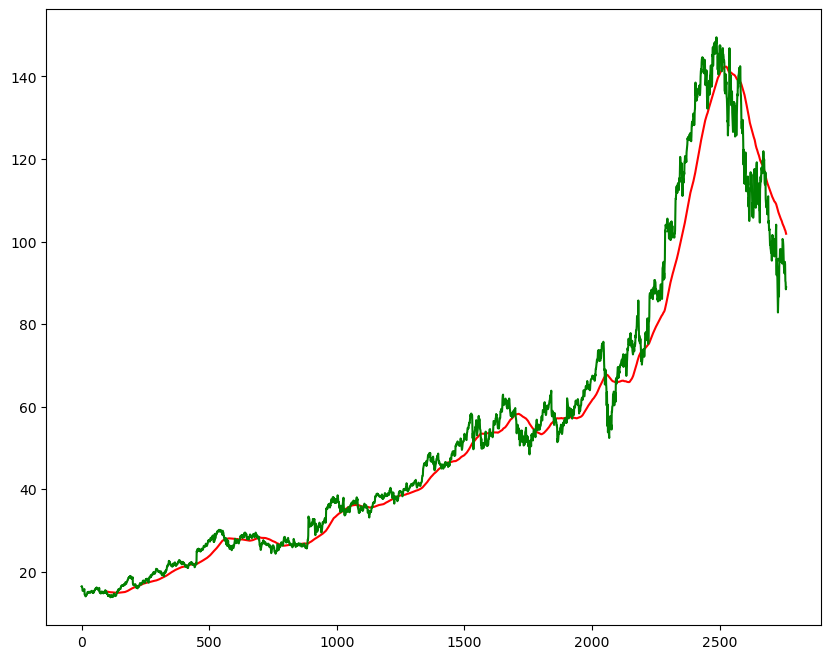

In [8]:
plt.figure(figsize = (10,8))
plt.plot(hundred_days,'r')
plt.plot(data.Close,'g')
plt.show()

In [9]:
Two_hundred_days = data.Close.rolling(200).mean()
Two_hundred_days


Ticker,GOOG
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2756,111.496582
2757,111.280598
2758,111.065127
2759,110.852016


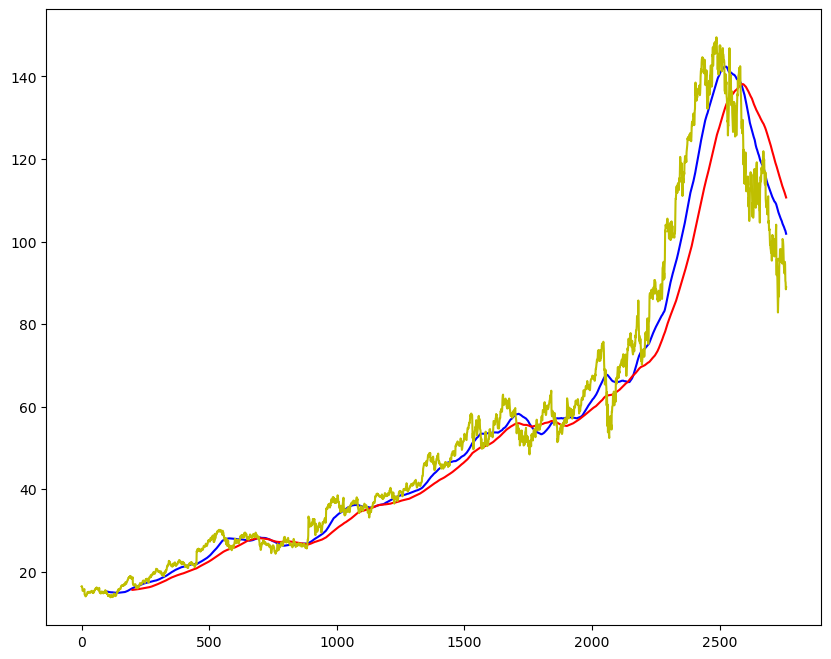

In [10]:
plt.figure(figsize = (10,8))
plt.plot(hundred_days,'b')
plt.plot(Two_hundred_days,'r')
plt.plot(data.Close,'y')
plt.show()

In [11]:
data.dropna(inplace = True)

In [12]:
data_train = pd.DataFrame(data.Close[0: int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[ int(len(data)*0.80) : len(data)])
data.shape[0]

2761

In [13]:
data_train.shape[0]

2208

In [14]:
data_test.shape[0]

553

In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))

In [16]:
data_train_scale = scaler.fit_transform(data_train)
data_train_scale

array([[0.03654391],
       [0.03753003],
       [0.03434499],
       ...,
       [0.81515354],
       [0.83283875],
       [0.85304157]], shape=(2208, 1))

In [17]:
x = []
y = []

for i in range(100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])

In [18]:
x, y = np.array(x), np.array(y)

from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

model = Sequential()

model.add(LSTM(
    units=50,
    activation='relu',
    return_sequences=True,
    input_shape=(x.shape[1], 1)
))
model.add(Dropout(0.2))

model.add(LSTM(
    units=60,
    activation='relu',
    return_sequences=True
))
model.add(Dropout(0.3))

model.add(LSTM(
    units=80,
    activation='relu',
    return_sequences=True
))
model.add(Dropout(0.4))

model.add(LSTM(
    units=120,
    activation='relu'
))

# OUTPUT LAYER
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.fit(
    x,
    y,
    epochs=10,
    batch_size=32,
    verbose=1
)

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 49s 296ms/step - loss: 0.0277
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 292ms/step - loss: 0.0021
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 270ms/step - loss: 0.0019
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 274ms/step - loss: 0.0020
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 283ms/step - loss: 0.0018
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 290ms/step - loss: 0.0017
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 291ms/step - loss: 0.0015
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 287ms/step - loss: 0.0014
Epoch 9/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 271ms/step - loss: 0.0016
Epoch 10/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 256ms/step - loss: 0.0013


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [20]:
hundred_days = data_train.tail(100)
data_test = pd.concat([hundred_days,data_test],ignore_index=True)

In [21]:
data_test

Ticker,GOOG
0,69.763245
1,69.568840
2,69.946739
3,70.274048
4,70.314713
...,...
648,94.533882
649,90.457352
650,90.120117
651,88.424042


In [22]:
data_test_scale = scaler.fit_transform(data_test)
data_test_scale

array([[0.02830226],
       [0.02593264],
       [0.03053889],
       [0.03452849],
       [0.03502416],
       [0.0343532 ],
       [0.04172216],
       [0.04347513],
       [0.0479483 ],
       [0.04623151],
       [0.03160276],
       [0.04744678],
       [0.05241562],
       [0.05818851],
       [0.06404602],
       [0.02656129],
       [0.03220742],
       [0.03623924],
       [0.05006405],
       [0.0551416 ],
       [0.04597764],
       [0.04341468],
       [0.0555891 ],
       [0.06317548],
       [0.0435658 ],
       [0.04922374],
       [0.        ],
       [0.02119954],
       [0.03246725],
       [0.04723503],
       [0.06335078],
       [0.08209003],
       [0.075731  ],
       [0.08227128],
       [0.09133267],
       [0.10992089],
       [0.09154433],
       [0.09712982],
       [0.0929348 ],
       [0.0955702 ],
       [0.09408906],
       [0.12441676],
       [0.12000365],
       [0.12609095],
       [0.09416773],
       [0.0918647 ],
       [0.10294511],
       [0.084

In [23]:
x = []
y = []

for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])

In [24]:
x, y = np.array(x), np.array(y)


In [25]:
y_predict = model.predict(x)

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step


In [26]:
scaler.scale_

array([0.01218911])

In [27]:
y_predict

array([[0.09700696],
       [0.09410954],
       [0.09149066],
       [0.08923212],
       [0.08738998],
       [0.08600033],
       [0.08505808],
       [0.08454083],
       [0.08443249],
       [0.08473399],
       [0.08546653],
       [0.08661204],
       [0.08813676],
       [0.08993229],
       [0.09189928],
       [0.09399454],
       [0.09620942],
       [0.09856573],
       [0.10119154],
       [0.104256  ],
       [0.10791954],
       [0.11231237],
       [0.11747455],
       [0.12340969],
       [0.12993471],
       [0.13690093],
       [0.14403206],
       [0.1511635 ],
       [0.15812583],
       [0.16479772],
       [0.1710655 ],
       [0.17683388],
       [0.18207629],
       [0.18680407],
       [0.19107671],
       [0.19492522],
       [0.19841798],
       [0.2016678 ],
       [0.20478189],
       [0.20784526],
       [0.21090141],
       [0.21396168],
       [0.21696936],
       [0.21983626],
       [0.22248429],
       [0.22482789],
       [0.22681117],
       [0.228

In [28]:
print('scale:',scaler.scale_)

scale: [0.01218911]


In [29]:
scale =1/scaler.scale_

In [30]:
scale

array([82.04045105])

In [31]:
y_predict = y_predict*scale

In [32]:
y_predict

array([[ 7.95849489],
       [ 7.72078933],
       [ 7.50593531],
       [ 7.32064312],
       [ 7.16951303],
       [ 7.05550592],
       [ 6.9782031 ],
       [ 6.93576775],
       [ 6.92687958],
       [ 6.95161499],
       [ 7.01171238],
       [ 7.10569069],
       [ 7.23077974],
       [ 7.37808525],
       [ 7.53945804],
       [ 7.71135409],
       [ 7.89306436],
       [ 8.08637674],
       [ 8.30179922],
       [ 8.55320899],
       [ 8.85376745],
       [ 9.21415742],
       [ 9.63766495],
       [10.12458651],
       [10.65990248],
       [11.23141418],
       [11.81645526],
       [12.40152201],
       [12.97271464],
       [13.52007955],
       [14.03429032],
       [14.50753152],
       [14.93762098],
       [15.32549025],
       [15.67601954],
       [15.99175287],
       [16.27830029],
       [16.54491732],
       [16.80039862],
       [17.05171853],
       [17.30244675],
       [17.55351239],
       [17.80026383],
       [18.03546633],
       [18.25271155],
       [18

In [33]:
y = y*scale
y

array([10.37728882, 10.50276947, 10.32423401,  9.88037109, 10.56872559,
        8.66436005,  9.72170258, 11.57546234, 12.66749573, 13.94054413,
       11.43361664, 12.11850739,  7.77218628, 10.28257751, 12.94918823,
       13.19813538, 14.39730072, 19.30301666, 20.00921631, 19.92887115,
       19.99087524, 18.8695755 , 19.48056793, 19.33821869, 20.68616486,
       20.90238953, 20.34546661, 19.18647766, 20.03649139, 18.95883942,
       18.59534454, 20.28248596, 20.40894318, 21.48806763, 19.87879944,
       21.73158264, 23.21192169, 23.15341187, 23.21391296, 22.79187775,
       22.74575043, 21.03876495, 20.60234833, 20.92173767, 19.84506989,
       20.22742462, 19.99087524, 19.24202728, 18.40439606, 18.81898499,
       18.03195953, 18.47233582, 18.79319763, 20.64004517, 19.77861023,
       18.82642365, 19.43939972, 18.26702881, 18.89586639, 18.61665344,
       21.1934967 , 22.18336487, 20.17536163, 19.17507172, 19.56437683,
       18.85916138, 18.66129303, 21.37252045, 26.13542175, 26.35

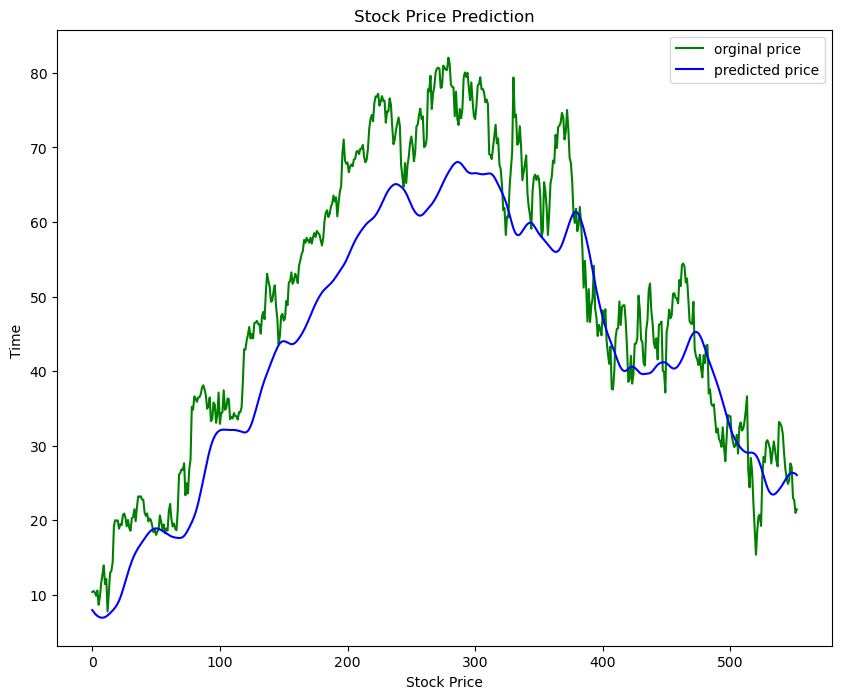

In [34]:
plt.figure(figsize = (10,8))
plt.plot(y,'g',label = 'orginal price' )
plt.plot(y_predict,'b',label = 'predicted price')
plt.xlabel('Stock Price')
plt.ylabel('Time ')
plt.title('Stock Price Prediction')
plt.legend()
plt.show()


In [35]:
model.save('Stock Prediction Model.keras')